22021.6012132417
127.11536053768826


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_77134/3022471752.py:32: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,700)


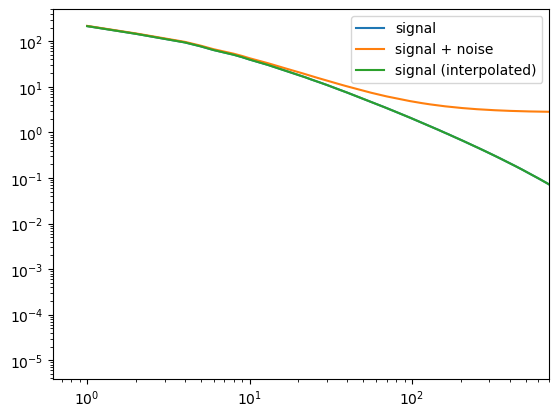

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

cell = np.load("cell_chime.npz")



ell = np.arange(1, cell["ell"].max())




variance = simpson(cell["cell"]*cell["ell"], cell["ell"])/(2*np.pi)

print(variance)

fksy = 0.5
n = 50000/4/np.pi/fksy

cell_noise = cell["cell"] + variance/n
dsnr = ((2*cell['ell'] + 1) * cell["cell"]/(cell_noise))/2*fksy
SNR = np.sum(dsnr[:2000])
print(SNR**.5)


plt.loglog(cell["ell"], cell["cell"], label="signal")
plt.loglog(cell["ell"], cell_noise, label="signal + noise")

plt.loglog(ell, np.interp(ell, cell["ell"], cell["cell"]), label="signal (interpolated)")
plt.legend()
plt.xlim(0,700)
#plt.xscale("linear")
plt.show()


np.savez("cell_chime.npz", ell=ell, cell=np.interp(ell, cell["ell"], cell["cell"]))